In [1]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display

In [2]:
df = spoti.load_all_tracks(data_path.DATA_PATH, users_list.USERS, load_spotify_tracks=True)
df

,album,artists,available_markets,disc_number,duration_ms,episode,explicit,external_ids,external_urls,href,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,affinity,release_year,normalized_genres
0,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,251488,False,False,{'isrc': 'GBF088590110'},{'spotify': 'https://open.spotify.com/track/4R...,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,...,audio_features,spotify:track:4RvWPyQ5RL0ao9LPZeSouE,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,https://api.spotify.com/v1/audio-analysis/4RvW...,251489,4,NaN,NaN,NaN,NaN
1,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,256146,False,False,{'isrc': 'GBF088590112'},{'spotify': 'https://open.spotify.com/track/74...,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,...,audio_features,spotify:track:748yv6bb3l3CcKS45a6SZ8,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,https://api.spotify.com/v1/audio-analysis/748y...,256147,4,NaN,NaN,NaN,NaN
2,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,209106,False,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,...,audio_features,spotify:track:7nhWtCc3v6Vem80gYPlppQ,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,https://api.spotify.com/v1/audio-analysis/7nhW...,209107,4,NaN,NaN,NaN,NaN
3,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,170786,False,False,{'isrc': 'GBUM71029609'},{'spotify': 'https://open.spotify.com/track/4v...,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,...,audio_features,spotify:track:4vhVDkSx9RSb2k6mWFMYNI,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,https://api.spotify.com/v1/audio-analysis/4vhV...,170787,4,NaN,NaN,NaN,NaN
4,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,264253,False,False,{'isrc': 'GBUM71029621'},{'spotify': 'https://open.spotify.com/track/5R...,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,...,audio_features,spotify:track:5RYLa5P4qweEAKq5U1gdcK,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,https://api.spotify.com/v1/audio-analysis/5RYL...,264253,4,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18123,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,...,audio_features,spotify:track:3z7dWKRsjDNM24ohLKZBnA,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,https://api.spotify.com/v1/audio-analysis/3z7d...,251880,4,NaN,NaN,1967.0,"[rock, rock, rock, rock, rock, rock, rock]"
18124,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,...,audio_features,spotify:track:1VofMhhL98pewltVGBSmCW,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,https://api.spotify.com/v1/audio-analysis/1Vof...,193853,3,NaN,NaN,2017.0,"[rock, rock, rock, rock, rock]"
18125,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,False,{'isrc': 'GBLTP170

In [3]:
plotting.plot_genres(df["genres"].head(300))

In [4]:
df["normalized_genres"].head(500)

0      NaN
1      NaN
2      NaN
3      NaN
4      NaN
      ... 
495    NaN
496    NaN
497    NaN
498    NaN
499    NaN
Name: normalized_genres, Length: 500, dtype: object

In [6]:
plotting.plot_genres(df["normalized_genres"])

In [ ]:
N_TOP_GENRES = 10

In [ ]:
df_genres_exploded = df.explode("normalized_genres")

In [ ]:
top_genres = df_genres_exploded.value_counts("normalized_genres").head(N_TOP_GENRES)
top_genres

normalized_genres
rap           10054
pop            6341
rock           4205
electronic     1557
indie          1517
french         1228
rnb            1162
metal           748
emo             605
jazz/blues      328
Name: count, dtype: int64

/var/folders/jy/ts_mdpfs04d36f2cz44nqbl00000gn/T/ipykernel_70208/3119677544.py:2: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



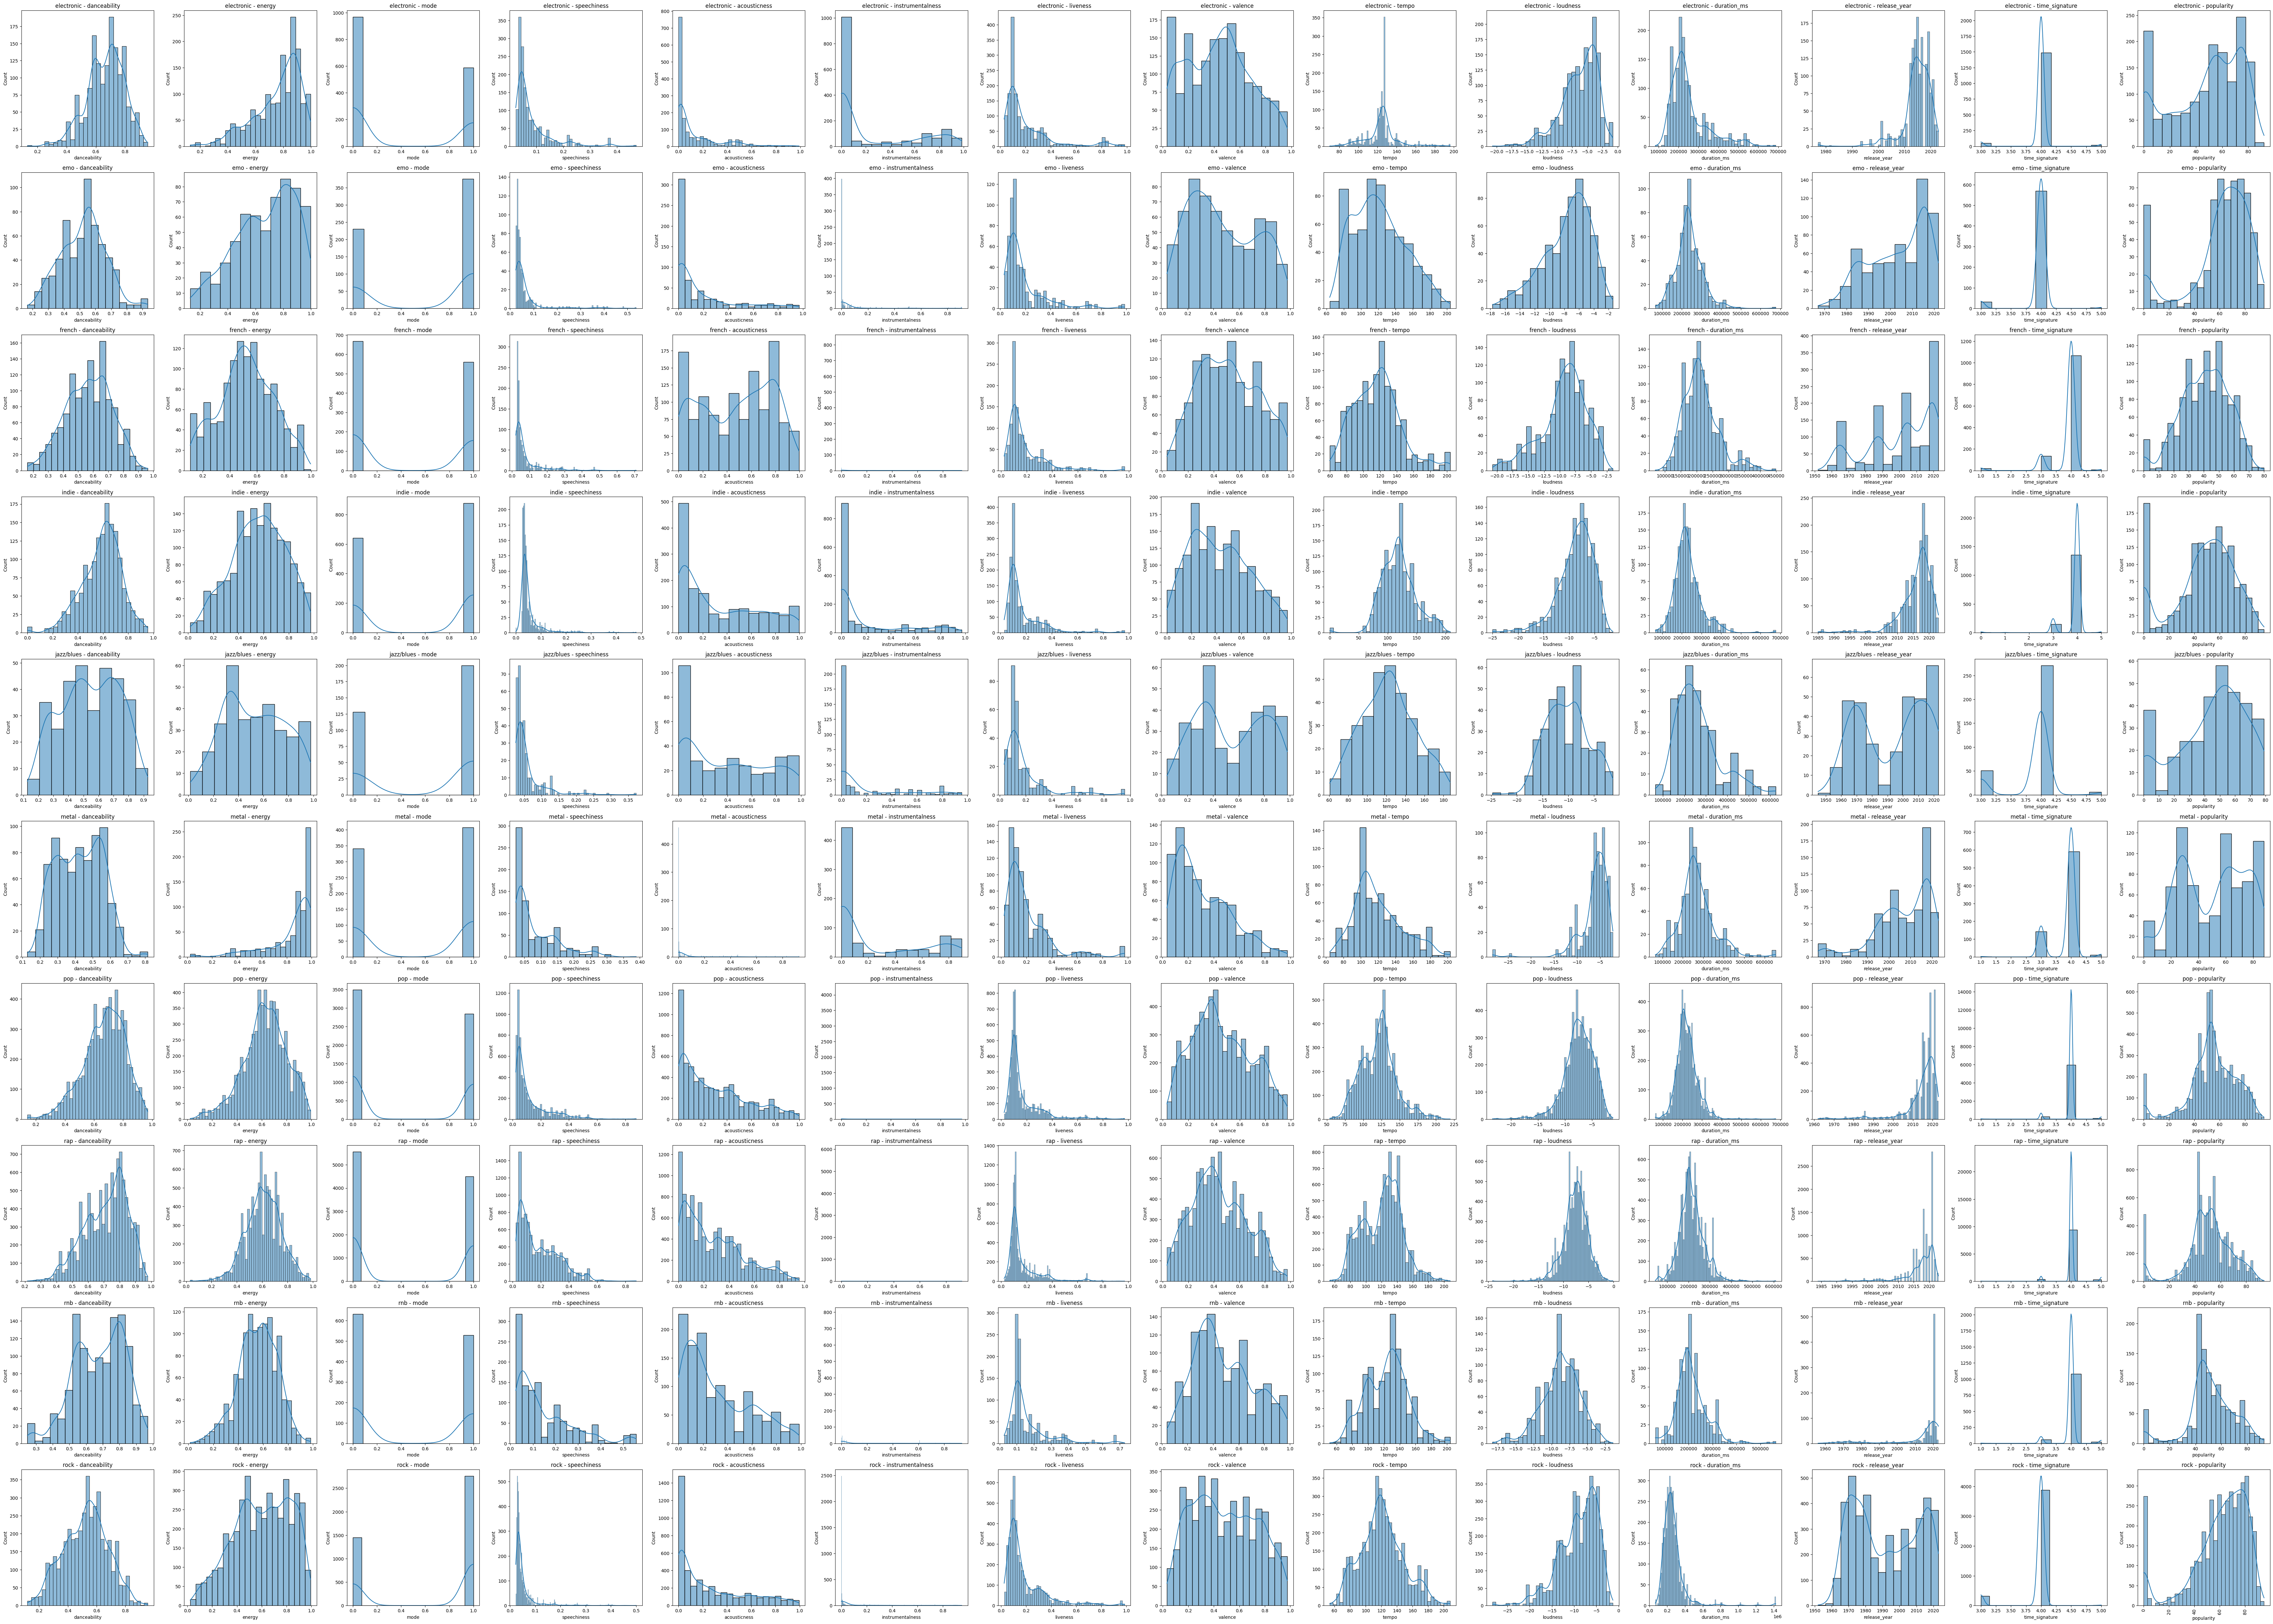

In [ ]:
df_top_genres = df_genres_exploded[df_genres_exploded["normalized_genres"].isin(top_genres.index.to_list())]
plotting.plot_column_distributions(df_top_genres.groupby("normalized_genres")).show()

In [ ]:
# take random <min_samples> samples from each genre
df_sample = pd.concat([df_top_genres[df_top_genres["normalized_genres"] == genre].sample(top_genres.min()) for genre in top_genres.index.to_list()])
assert df_sample.shape[0] == top_genres.min() * N_TOP_GENRES

In [ ]:
fig = px.scatter_matrix(
    df_sample,
    dimensions=spoti.NUMERICAL_FEATURES,
    color="normalized_genres",
    height=2200,
    width=1700,
)

fig.update_traces(showupperhalf=False)
fig.update_layout(title="Spotify Song Features")
fig.update_traces(marker=dict(opacity=0.1, line=dict(width=0.5, color="white")))

fig.show()